# 4. Back Propagaton II

Back propagation is the backbone of neural networks. Without it, we would not be able to effectively set the parameters of a neural network. Essentially, neural networks would be useless and just output random values. In this section, we will implement a back propagation to a simple neural network that only consists of a single neural in a hidden layer. We will train the neural network to replicate the results of an **OR gate** which has the following truth table, 

| Input 1   | Input 2 | Output |
| -------- | ------- | ------- |
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 1 |

The topology of the neural network is as follows, 

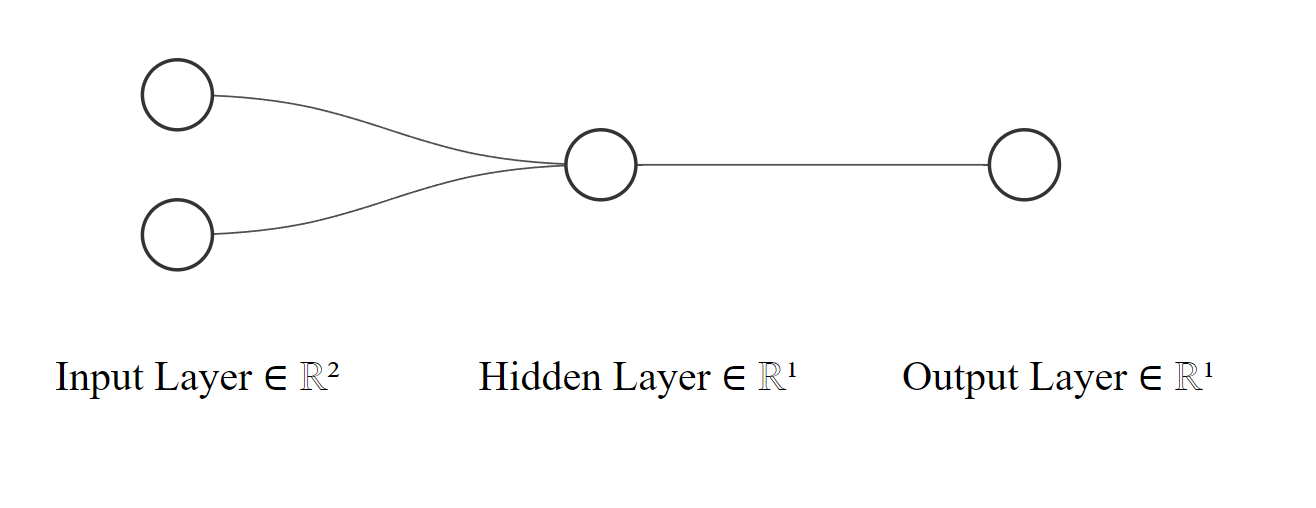

We have two neurons in the input layer for the binary input and then a single output neuron. The hidden layer output is **y_

In [1]:
import numpy as np

class LayerDENSE():
    """The LayerDENSE class implements a dense layer."""
    global LEARNING_RATE

    def __init__(self, n_inputs, n_neurons):
        """Constuctor method. The weights are initialised with random values between 0 and 1 while we construct
        the biases array as a zero array."""

        self.n_inputs = n_inputs
        self.n_neurons = n_neurons
        self.weights = np.random.rand(n_neurons, n_inputs)
        self.biases = np.zeros(n_neurons)
        self.input = None
        self.output = None
        self.weights_back = None
        self.biases_back = None

    def forward(self, input_array):
        """This method defines the forward propagation of the layer."""
        output_array = np.dot(input_array, self.weights.T)
        output_array += self.biases
        self.output = output_array
        self.input = input_array
        return None

    def backward(self, upstream):
        self.weights_back = upstream*self.input
        self.biases_back = upstream

        # Applying gradient descent,
        self.weights = self.weights - LEARNING_RATE*self.weights_back
        self.biases = self.biases - LEARNING_RATE*self.biases_back

    def __repr__(self):
        """Useful information for when the user prints the LayDense object."""
        repr_string = f"""Type: DENSE Layer,
        Number of Neurons: {self.n_neurons},
        Expected Input Array: (SAMPLE_SIZE, {self.n_inputs}),
        Output Array Shape: (SAMPLE_SIZE, {self.n_neurons})"""
        return repr_string

class Sigmoid():
    """This is the sigmoid activation function. It scales the input value between 0 and 1 in accordance 
    with the sigmoid curve."""

    def __init__(self):
        self.output = None
        self.back = None

    def forward(self, x):
        self.output = 1/(1 + np.exp(-1*x))
        return True

    def backward(self, upstream):
        if self.output is not None:
            self.back = upstream*self.output*(1 - self.output)
            return True
        else:
            return True

class MAE():
    """This is the class for the mean absolute error (MAE) loss function."""

    def __init__(self):
        self.output = None
        self.back = None

    def forward(self, x_predict, x_target):
        self.output = abs(x_target - x_predict)
        self.x_predict, self.x_target = x_predict, x_target
        return True

    def backward(self):
        if self.x_predict > self.x_target:
            self.back = 1
        elif self.x_predict < self.x_target:
            self.back = -1
        else:
            self.back = 1
        return True

class XORNetwork():
    """The class for the neural network model."""

    def __init__(self):
        """Constuctor method. The layers and activation functions of the neural network are created here."""

        # Creating layers,
        self.LAYER_1 = LayerDENSE(2, 1)

        # Creating activations,
        self.ACTIVATION_1 = Sigmoid()

        # Creating loss function, 
        self.MAE_LOSS = MAE()

        # Output and loss of the neural network,
        self.output = None
        self.loss = None
        self.target = None

    def forward_pass(self, binary_input, target):
        """The forward propagation of the the feed-forward neural network."""

        self.LAYER_1.forward(binary_input)
        self.ACTIVATION_1.forward(self.LAYER_1.output)

        # Setting the output of the NN,
        self.output = self.ACTIVATION_1.output

        # Calculating the loss,
        self.target = target
        self.MAE_LOSS.forward(self.output, self.target)
        self.loss = self.MAE_LOSS.output

        return True

    def backward_pass(self):
        self.MAE_LOSS.backward()
        self.ACTIVATION_1.backward(self.MAE_LOSS.back)
        self.LAYER_1.backward(self.ACTIVATION_1.back)

    def __repr__(self):
        print("Representation")

# Training Cycle

In [2]:
targets = [0, 1, 1, 1]
input_array = [[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]]

LEARNING_RATE = 1
EPOCHS = 1000

if __name__ == "__main__":
    NN = XORNetwork()
    for epoch in range(EPOCHS):
        losses = []
        for sample, target in zip(input_array, targets):
            NN.forward_pass(sample, target)
            NN.backward_pass()
            losses.append(NN.loss[0])
        print("Average Loss Per Epoch: " + str(np.mean(np.array(losses))))

Average Loss Per Epoch: 0.4373640268507951
Average Loss Per Epoch: 0.32279232332050034
Average Loss Per Epoch: 0.2767292629338568
Average Loss Per Epoch: 0.25581907313607927
Average Loss Per Epoch: 0.24418426451463043
Average Loss Per Epoch: 0.23651097403684804
Average Loss Per Epoch: 0.23073848830012844
Average Loss Per Epoch: 0.22593603811339819
Average Loss Per Epoch: 0.22162687707262346
Average Loss Per Epoch: 0.21754081897262345
Average Loss Per Epoch: 0.21351202062022157
Average Loss Per Epoch: 0.20943274470121384
Average Loss Per Epoch: 0.2052311766047187
Average Loss Per Epoch: 0.20086052168681337
Average Loss Per Epoch: 0.19629369704364433
Average Loss Per Epoch: 0.19152076911440946
Average Loss Per Epoch: 0.1865475052386877
Average Loss Per Epoch: 0.18139400047761553
Average Loss Per Epoch: 0.17609273180189167
Average Loss Per Epoch: 0.17068575493428617
Average Loss Per Epoch: 0.16522112669749076
Average Loss Per Epoch: 0.15974894770635883
Average Loss Per Epoch: 0.1543175858

In [1]:
for sample, target in zip(input_array, targets):
    NN.forward_pass(sample, target)
    print(NN.output)

NameError: name 'input_array' is not defined